In [1]:
#header imports and function defs:
import os, sys
import numpy as np
import scipy as sp
from netCDF4 import Dataset as ncopen 
from eofs.standard import Eof
import matplotlib.pyplot as plt
font = {'size'   : 16}
plt.rc('font', **font)
nLvls = 61
colors = ['#d73027', '#fc8d59', '#91bfdb', '#4575b4','#000000']


In [ ]:
##helper functions
def set_cBar(MX,MN=None,nLevs=61,nLab=4):
    if MN==None:MN=-MX
    clevs = np.linspace(MN, MX, nLevs)
    labels = np.arange(0, np.ceil(MX)+1,np.maximum(np.ceil(MX)//nLab,1))
    labels = np.concatenate((-np.flip(labels[1:]),labels[:]))
    if (MX<2)&(MX>1):labels = np.array((-1.6,-1.2,-.8,-.4,0,.4,.8,1.2,1.6))
    if (MX<=1):labels = np.array((-1,-.8,-.6,-.4,-.2,0,.2,.4,.6,.8,1))
    #elif MX<=1:labels = np.array((-1,-.8,-.6,-.4,-.2,0,.2,.4,.6,.8,1))
    #else:#np.arange(-np.ceil(MX)+np.ceil(MX)%nLab, np.ceil(MX)+1,np.maximum(np.ceil(MX)//nLab,1))
    return clevs,labels

def make_daily(varIn,ops=4,pad=False):
    nDim=np.ndim(varIn)
    if nDim>1:
        opDim=np.argmax(np.shape(varIn))
        varIn=np.rollaxis(varIn,opDim)
        if pad:
            if (np.shape(varIn)[0])%ops:
                if (np.shape(varIn)[0])%ops==3:
                    varAvg=np.nan*np.zeros((tuple([np.shape(varIn)[0]+1])+np.shape(varIn)[1:])).astype(np.float32)
                    varAvg[1:,...]=varIn
                if (np.shape(varIn)[0])%ops==2:
                    varAvg=np.nan*np.zeros((tuple([np.shape(varIn)[0]+2])+np.shape(varIn)[1:])).astype(np.float32)
                    varAvg[2:,...]=varIn
                if (np.shape(varIn)[0])%ops==1:
                    varAvg=np.nan*np.zeros((tuple([np.shape(varIn)[0]-1])+np.shape(varIn)[1:])).astype(np.float32)
                    varAvg=varIn[1:,...]
            else:varAvg=varIn
        varIndaily=np.nanmean(varIn.reshape((tuple([int(np.shape(varIn)[0]/ops)])+tuple([ops])+np.shape(varIn)[1:])),axis=1).squeeze()
        varInavgdaily=(np.nanmean(varIndaily,axis=0).squeeze())
    
        for _ in range(varIn.ndim-opDim+1):varIndaily=np.rollaxis(varIndaily,opDim)

    else:
        if pad:
            if (np.shape(varIn)[0])%ops:
                if (np.shape(varIn)[0])%ops==3:
                    varAvg=np.nan*np.zeros((np.shape(varIn)[0]+1)).astype(np.float32)
                    varAvg[1:,:,:]=varIn
                if (np.shape(varIn)[0])%ops==2:
                    varAvg=np.nan*np.zeros((np.shape(varIn)[0]+2)).astype(np.float32)
                    varAvg[2:,:,:]=varIn
                if (np.shape(varIn)[0])%ops==1:
                    varAvg=np.nan*np.zeros((np.shape(varIn)[0]-1)).astype(np.float32)
                    varAvg=varIn[1:,:,:]
            else:varAvg=varIn
        varIndaily=np.nanmean(varIn.reshape((int(np.shape(varIn)[0]/ops)),ops),axis=1).squeeze()
        varInavgdaily=(np.nanmean(varIndaily,axis=0).squeeze())

    return np.array(varIndaily),np.array(varInavgdaily)

def simple_detrend(varin,time=False):
    """
    simple_trend_det; battalio 2022
    find the linear trend in the varin for a given time
    varin is the 1D (time) or 3D dataset (space, space, time)
    returns the slope, r Value, p, standard error of the fit
    includes returning a detrended variable without removing the mean
    """
    opDim=np.argmax(np.shape(varin))
    varin=np.rollaxis(varin,opDim)
    if not time:time=np.arange(np.shape(varin)[0])
    
    detrendVar  = np.zeros_like(varin)*np.nan
    
    if varin.ndim==1:
        mask = np.isfinite(varin[:])
        if (~mask).all():print("No valid points.")
        m, _, _, pVal, stdErr  = sp.stats.linregress(time[mask],varin[mask])
        detrendVar[mask] = varin[mask] - (m*time[mask])
    else:
        m   = np.zeros((np.shape(varin)[1],np.shape(varin)[2]))*np.nan
        pVal = np.copy(m)
        stdErr=np.copy(m)
    
        for i in range(0,np.shape(varin)[1]):
            for j in range(0,np.shape(varin)[2]):
                mask = np.isfinite(varin[:,i,j])
                if (~mask).all():continue  #if there are no points in the regression, skip
                
                m[i,j], b, _, pVal[i,j], stdErr[i,j]  = sp.stats.linregress(time[mask],varin[mask,i,j])
                detrendVar[mask,i,j] = varin[mask,i,j] - (m[i,j]*time[mask] + b)

        for _ in range(varin.ndim-opDim+1):detrendVar=np.rollaxis(detrendVar,opDim)

    return detrendVar,m,pVal,stdErr

def EOF_wrapper(varIn,idxEOFNot=None,nEOFs=3,oneD=True,stdScalling=True,varProj=None,nlags=241,corrIdx=-1):
    #1D or 2D EOF calculation on vertical average zonal-mean (latitude only)
    opDim=np.argmax(np.shape(varIn))
    varIn=np.rollaxis(varIn,opDim)
    if varProj is not None:varProj=np.rollaxis(varProj,opDim)
    if oneD:
        varIn2D=np.copy(varIn)
        varIn=np.nanmean(varIn[:,:,:],axis=1)
        if varProj is not None:varProj=np.nanmean(varProj[:,:,:],axis=1)

    if idxEOFNot is not None:
        varInEof=np.copy(varIn)
        varInEof[idxEOFNot,:]=0
    else:varInEof=varIn

    AMsolver = Eof(varInEof)
    AMpcs = AMsolver.pcs(npcs=nEOFs, pcscaling=0)
    AMeofs = AMsolver.eofs(neofs=nEOFs, eofscaling=0)
    if stdScalling:
    	pcmaxes = np.std((AMpcs),axis=0)
    	AMpcs = AMpcs/pcmaxes
    	if oneD:AMeofs = AMeofs*pcmaxes[:,None]
    	else:AMeofs = AMeofs*pcmaxes[:,None,None]
        	
    AMreconstr = AMsolver.reconstructedField(neofs=1)
    AMvarfrac = AMsolver.varianceFraction()
    AMlambdas = AMsolver.eigenvalues()
    UAM = AMsolver.projectField(varIn,neofs=2)
    if varProj is not None:MAM = AMsolver.projectField(varProj,neofs=2)

    AMnorth = AMsolver.northTest(vfscaled=False)
    CI = np.zeros_like(AMnorth)
    # built-in Northtest overestimats as dof=len(pcs); use autocorrelation to find 
    # effective dof (n*=n(1+2*sum(1-lag/len(t)*autocorrelation(at lag)))^-1
    # see Hannachi et al. 2007 Int. J. of Clim.
    for ii in range(0,nEOFs):
        rho=AMpcs[:,ii]
        n=len(rho)
        tot=0
        for k in range (1,n-2):
            try:_,_,_,_,alpha=simple_stats_nan(rho,rho,lag=k)
            except:alpha=0
            tot=tot+(alpha*(1-k/(n)))
        nStar=n/((1+2*np.abs(tot)))
        CI[ii]=np.sqrt(2/nStar)
    CI=CI*AMvarfrac
    
    #set poleward side as positive node
    if np.nanmean(AMeofs[0:2])<0:
        AMeofs[0,:]=-1*AMeofs[0,:]
        AMpcs[:,0]=-1*AMpcs[:,0]
        UAM[:,0]=-1*UAM[:,0]
        if varProj is not None:MAM[:,0]=-1*MAM[:,0]
    #set center of tripole as positive node
    centLat=int(np.shape(AMeofs)[1]/2)
    if np.nanmean(AMeofs[1,centLat])<0:
        AMeofs[1,:]=-1*AMeofs[1,:]
        AMpcs[:,1]=-1*AMpcs[:,1]
        UAM[:,1]=-1*UAM[:,1]
        if varProj is not None:MAM[:,1]=-1*MAM[:,1]

    var1,_=rollavg_1Dconvolve(varIn,11)      
    var2,_=rollavg_1Dconvolve(AMreconstr,11)

    if idxEOFNot is not None:
        var1[idxEOFNot,:]=np.nan
        var2[idxEOFNot,:]=np.nan
    
    if oneD:
        AMlags=np.zeros((2,nlags,np.shape(var1)[1]))
        for i in range(0,nlags):
            _,_,_,_,AMlags[0,i,:]=simple_stats_nan(var1[:,corrIdx],var1[:,:],lag=i-int(np.round(nlags/2)))
            _,_,_,_,AMlags[1,i,:]=simple_stats_nan(var2[:,corrIdx],var2[:,:],lag=i-int(np.round(nlags/2)))

        #if we flattened the zonal-mean to just 1d, construct 2D eofs
        AMeofs2D=np.zeros((nEOFs,np.shape(varIn2D)[1],np.shape(varIn2D)[2]))
        if idxEOFNot is not None:varIn2D[idxEOFNot,:,:]=np.nan
        for ii in range(0,nEOFs):AMeofs2D[ii,:,:],_,_,_,_=simple_stats_nan(AMpcs[:,ii],varIn2D)
    else:
        AMeofs2D=np.copy(AMeofs)
        AMlags=np.copy(AMeofs)
        
    if varProj is not None:return AMpcs,AMeofs,AMreconstr,AMvarfrac,CI,UAM,MAM,AMlags,AMeofs2D,AMlambdas,AMnorth
    else:return AMpcs,AMeofs,AMreconstr,AMvarfrac,CI,UAM,np.array((0)),AMlags,AMeofs2D,AMlambdas,AMnorth

def simple_stats_nan(varin1,varin2,lag=0,norm=False,doublenorm=False):
    """
    simple_stats_nan; battalio 2022–2024
    Regress and correlate 1D timeseries on a dataset of 1D/2D/3D data potentially containing NaNs
    varin1 is a 1D vector or 3D dataset, can be UTC to find a trend or any 1D timeseries
    varin2 is a 1D/2D/3D dataset; time dimension is assumed the longest dimension
    keyword lag is for lead-lag regressions; move varin1 variable forward if lag>0; otherwise move varin2 forward if lag<0
    returns the 0D/1D/2D regression coefficients, r Value, p Value, standard error of the fit, Pearson correlation coefficient
    """
    lag=int(lag)
    nDim1=np.ndim(varin1)
    nDim2=np.ndim(varin2)

    if nDim1==1:  #if varin1 is a 1D timeseries
        if lag>0:varin1=varin1[:-lag] #if any value other than zero modify the input variables to handle the lag
        if lag<0:varin1=varin1[-lag:]
        
        if nDim2==1:
            if lag>0:varin2=varin2[lag:]
            if lag<0:varin2=varin2[:lag]
            mask = (np.isfinite(varin1[:]) & np.isfinite(varin2[:]))
            if ((~mask).all())|(len(np.unique(varin1[mask]))<3)|(len(np.unique(varin2[mask]))<3):
                print("Insufficient x or y values to perform statistics")  #if there are no points in the regression, skip
            else:
                corr = np.corrcoef(varin1[mask],varin2[mask])[0,1]
                if norm:varin1[mask]=(varin1[mask]/np.nanstd(varin1[mask]))
                if doublenorm:varin2[mask]=(varin2[mask]/np.nanstd(varin2[mask]))
                m, intercept, rVal, pVal, stdErr = sp.stats.linregress(varin1[mask],varin2[mask])
        elif nDim2==2:
            varin2=np.rollaxis(varin2,np.argmax(np.shape(varin2)))  #shift axes so that the longest dimension (assumed to be time) is the first
            if lag>0:varin2=varin2[lag:,:]
            if lag<0:varin2=varin2[:lag,:]        		
            m = np.zeros((np.shape(varin2)[1]))*np.nan
            rVal = np.copy(m)
            pVal= np.copy(m)
            stdErr = np.copy(m)
            corr = np.copy(m)
            
            for i in range(0,np.shape(varin2)[1]):
                mask = (np.isfinite(varin1[:]) & np.isfinite(varin2[:,i]))
                if ((~mask).all())|(len(np.unique(varin1[mask]))<3)|(len(np.unique(varin2[mask,i]))<3):continue  #if there are no points in the regression, skip
                corr[i] = np.corrcoef(varin1[mask],varin2[mask,i])[0,1]
                xVar=varin1[mask]
                yVar=varin2[mask,i]
                if norm:xVar=(xVar/np.nanstd(xVar))
                if doublenorm:yVar=(yVar/np.nanstd(yVar))
                m[i], _, rVal[i], pVal[i], stdErr[i]  = sp.stats.linregress(xVar,yVar)
                
        elif nDim2==3:
            varin2=np.rollaxis(varin2,np.argmax(np.shape(varin2)))  #shift axes so that the longest dimension is the first
            if lag>0:varin2=varin2[lag:,:,:]
            if lag<0:varin2=varin2[:lag,:,:]
            		
            m = np.zeros((np.shape(varin2)[1],np.shape(varin2)[2]))*np.nan
            rVal = np.copy(m)
            pVal= np.copy(m)
            stdErr=np.copy(m)
            corr=np.copy(m)
            
            for i in range(0,np.shape(varin2)[1]):
            	for j in range(0,np.shape(varin2)[2]):
                    mask = (np.isfinite(varin1[:]) & np.isfinite(varin2[:,i,j]))
                    if ((~mask).all())|(len(np.unique(varin1[mask]))<3)|(len(np.unique(varin2[mask,i,j]))<3):continue  #if there are no points in the regression, skip
                    corr[i,j] = np.corrcoef(varin1[mask],varin2[mask,i,j])[0,1]
                    xVar=varin1[mask]
                    yVar=varin2[mask,i,j]
                    if norm:xVar=(xVar/np.nanstd(xVar))
                    if doublenorm:yVar=(yVar/np.nanstd(yVar))
                    m[i,j], _, rVal[i,j], pVal[i,j], stdErr[i,j]  = sp.stats.linregress(xVar,yVar)

        else:print("varin2 must be no more than 3D with 1 time dimension")
        
    elif nDim1==3 and nDim2==3:  #if varin1 and varin2 are a 3D datasets
        varin1=np.rollaxis(varin1,np.argmax(np.shape(varin1)))  #shift axes so that the longest dimensionis the first
        varin2=np.rollaxis(varin2,np.argmax(np.shape(varin2)))
        if lag>0:
            varin1=varin1[:-lag,:,:] #if any value other than zero modify the input variables to handle the lag
            varin2=varin2[lag:,:,:]
        if lag<0:
            varin1=varin1[-lag:,:,:]
            varin2=varin2[:lag,:,:]

        m   = np.zeros((np.shape(varin2)[1],np.shape(varin2)[2]))*np.nan
        rVal = np.copy(m)
        pVal = np.copy(m)
        stdErr=np.copy(m)
        corr=np.copy(m)
        
        for i in range(0,np.shape(varin2)[1]):
            for j in range(0,np.shape(varin2)[2]):
                mask = (np.isfinite(varin1[:,i,j]) & np.isfinite(varin2[:,i,j]))
                if ((~mask).all())|(len(np.unique(varin1[mask,i,j]))<3)|(len(np.unique(varin2[mask,i,j]))<3):continue  #if there are no points in the regression, skip
                corr[i,j] = np.corrcoef(varin1[mask,i,j],varin2[mask,i,j])[0,1]
                xVar=varin1[mask,i,j]
                yVar=varin2[mask,i,j]
                if norm:xVar=(xVar/np.nanstd(xVar))
                if doublenorm:yVar=(yVar/np.nanstd(yVar))
                b[i,j], _, rVal[i,j], pVal[i,j], stdErr[i,j]  = sp.stats.linregress(xVar,yVar)

    else:print("varin1 must be either 1D timeseries or same dimension as varin2")
    
    return m,rVal,pVal,stdErr,corr

def rollavg_1Dconvolve(varin,n,wrap=False,square=False):
    'np.convolve, with edge handling for timeseries'
    'varin is the vector to smooth, n is the number of points over which to do so'
    'use wrap=True if the domain is circular (like over a latitude circle)'
    'use square=True a boxcar filter is used instead of guassian'
    'returns the rolling convolve and the deviation from said convolve'
    
    sx=n/5
    x=np.linspace(1,n,n+1)
    Xyc=np.ceil(n/2)
    h= np.exp(-((x - Xyc)**2. / (2. * sx**2.)))
    h=h/np.sum(h)
    if square:h=np.ones(n,dtype='float')
    
    nDim=np.ndim(varin)
    
    if nDim==1:
        if wrap:
            varinA = np.append(varin,varin[:int(np.floor(n/2))],axis=0)
            varinA = np.append(varin[-int(np.ceil(n/2)):],varinA,axis=0)
            #conv with 'valid' only returns full overlap
            conv=np.convolve(varinA,h, 'valid')/np.convolve(np.ones(len(varinA)),h, 'valid') 
        else:
            # conv with 'same' returns same length as a
            conv=np.convolve(varin,h, 'same')/np.convolve(np.ones(len(varin)),h, 'same') 

    else:
        opDim=np.argmax(np.shape(varin))
        varin=np.rollaxis(varin,opDim)
        shp=np.shape(varin)
        varin=np.reshape(varin,(shp[0],-1))
        conv=np.zeros_like(varin)*np.nan
        kern=np.convolve(np.ones(np.shape(varin)[0]),h, 'same')
        
        for i in range(0,np.shape(varin)[1]):
            #mask = (np.isfinite(varin[:,i,j]))
            #if (~mask).all():  #if there are no points in the regression, skip
            #    continue
            conv[:,i]=np.convolve(varin[:,i],h, 'same')/kern

        varin=np.reshape(varin,(shp))
        conv=np.reshape(conv,(shp))
     
        for _ in range(varin.ndim-opDim+1):
            conv=np.rollaxis(conv,opDim)
            varin=np.rollaxis(varin,opDim)

    return conv,varin-conv

def welch_powerspectrum(timeseries,fs=1,N=3,Nreal=8):
	_,_,_,_,alpha=simple_stats_nan(timeseries,timeseries,lag=1)
	Te = -1/np.log(alpha)
	print(np.round(alpha,3),np.round(Te,2))
	timeseries[np.isnan(timeseries)]=0

	T = len(timeseries)         #length of time series
	beta = np.sqrt(1.-alpha**2)  #beta, red noise parameter
	T2 = np.round(T/(2*N))
	freq = np.arange(0.,T2)/(T/N)

	# contstruct expected red noise spectrum 
	rspec = []
	for h in np.arange(0,T2):rspec.append((1.-alpha**2)/(1.-2.*alpha*np.cos(np.pi*(h)/T2)+alpha**2))
	
	# compute power spectrum on one realization
	pAve = sp.signal.welch(timeseries,fs=fs,window='hann', nperseg=int(np.floor(T/N)))[1]
	# normalize the spectrum
	pAve1 = (pAve/np.sum(pAve))[:len(freq)]

	paveArr=np.zeros((len(pAve1),N*Nreal))
	# loop over realizations
	for ir in np.arange(1,np.shape(paveArr)[1]+1):
		# compute power spectrum
		a,b = sp.signal.welch(timeseries,fs=fs,window='hann', nperseg=int(np.floor(T/ir)))
		#a,b = sp.signal.welch(timeseries, 1,'flattop', (-1)**i*i*50+nperseg,scaling='density',average='mean')
		paveArr[:,ir-1]=np.interp(freq, a, b)

	# calculate significance using F-test
	dof = 2.*(N*Nreal+1.) #dof = 2*N*1.2
	fstat = sp.stats.f.ppf(.95,dof,100000)#
	rspecP95 = [fstat*m for m in rspec]
	rspecM95 = [(1/fstat)*m for m in rspec]
    
	# normalize the spectrum
	rspecM95 = rspecM95/np.sum(rspec)
	rspecP95 = rspecP95/np.sum(rspec)
	rspec = rspec/np.sum(rspec)
    
	pSum = np.nanmean(paveArr,axis=1)
	#pErr = 1.96*np.nanstd(paveArr,axis=1)/np.sqrt(np.shape(paveArr)[0])
	pErr = sp.stats.sem(paveArr,axis=1) * sp.stats.t.ppf((1+.95)/2, ir-1) #~1.96

	# calculate average    
	pAve = pSum/(N*Nreal+1.0)
	pAveP95=(pSum+pErr)/(N*Nreal+1.0)
	pAveM95=(pSum-pErr)/(N*Nreal+1.0)

	# normalize the spectrum
	pAveP95 = pAveP95/np.sum(pAve)
	pAveM95 = pAveM95/np.sum(pAve)
	pAve = pAve/np.sum(pAve)
	
	return freq,pAve,pAveM95,pAveP95,rspec,rspecM95,rspecP95

def fft_anom(varIn, cutoff, ops, order=5,pad=True):
    nyq = 0.5 * ops
    normal_cutoff = cutoff / nyq
    if isinstance(cutoff, float):sos = sp.signal.butter(order, normal_cutoff, btype='lowpass', analog=False, output='sos')
    else:sos = sp.signal.butter(order, normal_cutoff, btype='bandpass', analog=False, output='sos')

    if varIn.ndim>1:
        opDim=np.argmax(np.shape(varIn))
        varIn=np.rollaxis(varIn,opDim)
        
        if pad:varBar = sp.signal.sosfiltfilt(sos, varIn,axis=0,padlen=np.max(np.int64(1/cutoff)*3*ops))
        else:varBar = sp.signal.sosfiltfilt(sos, varIn,axis=0)
            
        for _ in range(varIn.ndim-opDim+1):
            varBar=np.rollaxis(varBar,opDim)
            varIn=np.rollaxis(varIn,opDim)
    else:
    	if pad:varBar = sp.signal.sosfiltfilt(sos, varIn,axis=0,padlen=np.max(np.int64(1/cutoff)*3*ops))
    	else:varBar = sp.signal.sosfiltfilt(sos, varIn,axis=0)
        
    return varIn-varBar,varBar

In [3]:
#load data
reanalysis="OMARS"
npzfile=np.load("/Users/battalio/Mars/"+reanalysis+"/TES_zonal.npz")
sfc=sp.io.loadmat('zsurfOMARS.mat')['sfc']
ops=12 #OPENMARS/MACDA
PlevIdx=np.array((0,1,2,3,4,5,6,7,8,9,10,11,13,15,17,19,21,22,24,26,27,28,29)).astype(int)#OMARS

if reanalysis=="EMARS":
    npzfile=np.load("/Users/battalio/Mars/"+reanalysis+"/memb/MCS_zonal.npz")
    ops=24 #EMARS

uZonal=(npzfile['uZonal'])[:,PlevIdx,:]
ekeZonal=(npzfile['ekeZonal'])[:,PlevIdx,:]
heatFluxZonal=(npzfile['hozHeatFluxZonal'])[:,PlevIdx,:]
momFluxZonal=(npzfile['hozMomFluxZonal'])[:,PlevIdx,:]
lats=np.round(np.squeeze(npzfile['lats']),2)
lons=np.round(np.squeeze(npzfile['lons']),2)
plevs=np.squeeze(npzfile['plevs'])[PlevIdx]

if reanalysis=="EMARS": #if EMARS, flip lat axis
    uZonal=np.flip(uZonal,axis=2)
    ekeZonal=np.flip(ekeZonal,axis=2)
    heatFluxZonal=np.flip(heatFluxZonal,axis=2)
    momFluxZonal=np.flip(momFluxZonal,axis=2)
    lats=np.flip(lats,axis=0)
    soy=np.squeeze(npzfile['soy'])[::ops].astype(int)

MYs=np.squeeze(npzfile['MY'])[::ops]
lss=np.squeeze(npzfile['lss'])[::ops]
MYlss=MYs+lss/360
sols=(np.round(np.squeeze(npzfile['sols'])[::ops])).astype(int)

idxTime=np.argwhere((MYlss>28.999999) & (MYlss<36.004))[:,0]  ##PLUS a bit of MY36 to make it 669 sols each MY for 7 years
idxTime=np.argwhere((MYlss<36.004))[:,0]  ##PLUS a bit of MY36 to make it 669 sols each MY for 7 years
MYlss=MYlss[idxTime]
lss=lss[idxTime]
MYs=MYs[idxTime]
sols=sols[idxTime]
soy=(sols-sols[0])%669

dta = ncopen("/Users/battalio/Mars/OMARS/MCS_ret_coverage.nc",'r')
Cov = np.nansum(np.array(dta.variables['MCS_T_profiles'][:]).astype(np.float32),axis=1)
Cov=np.interp(np.arange(len(Cov)*2)/2,np.arange(len(Cov)),Cov<300)[idxTime]
#Cov,_=rollavg_1Dconvolve(Cov,20,wrap=False)
Cov=Cov>.09
diff=(np.diff(Cov.astype(int)))
startT=np.where(diff>0)[0]
endT=np.where(diff<0)[0]
if startT[0]>endT[0]:startT=np.concatenate(([0],startT.squeeze()))
times=list(zip(MYlss[startT],MYlss[endT]))

uZonal,_=make_daily(uZonal,ops=ops)
ekeZonal,_=make_daily(ekeZonal,ops=ops)
momFluxZonal,_=make_daily(momFluxZonal,ops=ops)
heatFluxZonal,_=make_daily(heatFluxZonal,ops=ops)

momFluxZonal=np.moveaxis(momFluxZonal[idxTime,:,:],[0, 1, 2], [2, 0, 1])
heatFluxZonal=np.moveaxis(heatFluxZonal[idxTime,:,:],[0, 1, 2], [2, 0, 1])
ekeZonal=np.moveaxis(ekeZonal[idxTime,:,:],[0, 1, 2], [2, 0, 1])
uZonal=np.moveaxis(uZonal[idxTime,:,:],[0, 1, 2], [2, 0, 1])

sqrtLats=np.sqrt(np.abs(np.cos(lats*np.pi/180))).squeeze()
levDiff=np.diff(np.append(plevs, 0)).astype(float)*(-1)#np.sqrt(plevs/np.nanmax(plevs))
levDiff=(levDiff/np.nanmax(levDiff))#levDiff=np.sqrt(levDiff/np.nanmax(levDiff))
sqrtLev,_=rollavg_1Dconvolve(levDiff,3)

idx85N=(np.abs(lats - 85)).argmin()
idx80N=(np.abs(lats - 80)).argmin()
idx75N=(np.abs(lats - 75)).argmin()
idx25N=(np.abs(lats - 25)).argmin()+1
idx25S=(np.abs(lats - (-25))).argmin()
idx85S=(np.abs(lats - (-85))).argmin()+1
lev1=3
lev2=17


/var/folders/8m/8grm1g_x1q3d9vn_zvj_62th0000gn/T/ipykernel_13993/448656980.py:30: RuntimeWarning: Mean of empty slice
  varIndaily=np.nanmean(varIn.reshape((tuple([int(np.shape(varIn)[0]/ops)])+tuple([ops])+np.shape(varIn)[1:])),axis=1).squeeze()
/var/folders/8m/8grm1g_x1q3d9vn_zvj_62th0000gn/T/ipykernel_13993/448656980.py:31: RuntimeWarning: Mean of empty slice
  varInavgdaily=(np.nanmean(varIndaily,axis=0).squeeze())


In [4]:
uZonalWeight=uZonal*sqrtLats[None,:,None]*sqrtLev[:,None,None]
ekeZonalWeight=ekeZonal*sqrtLats[None,:,None]*sqrtLev[:,None,None]

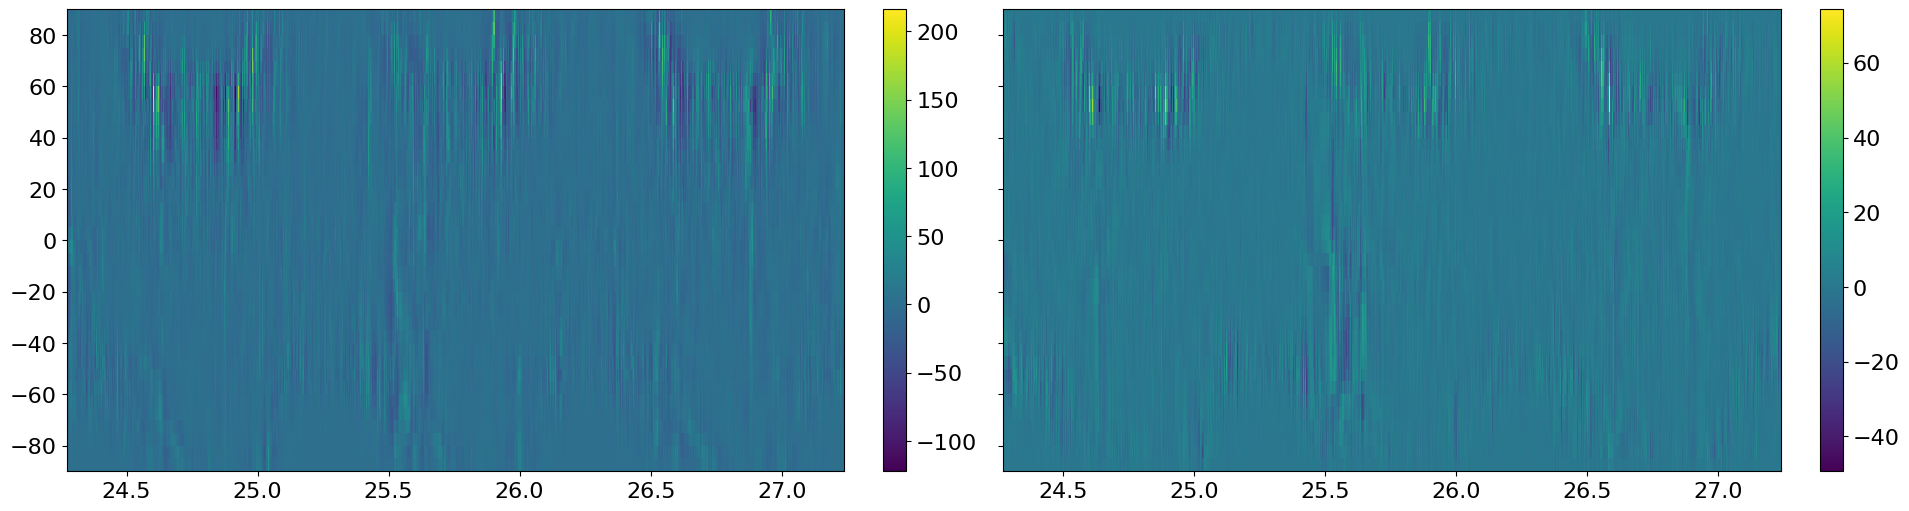

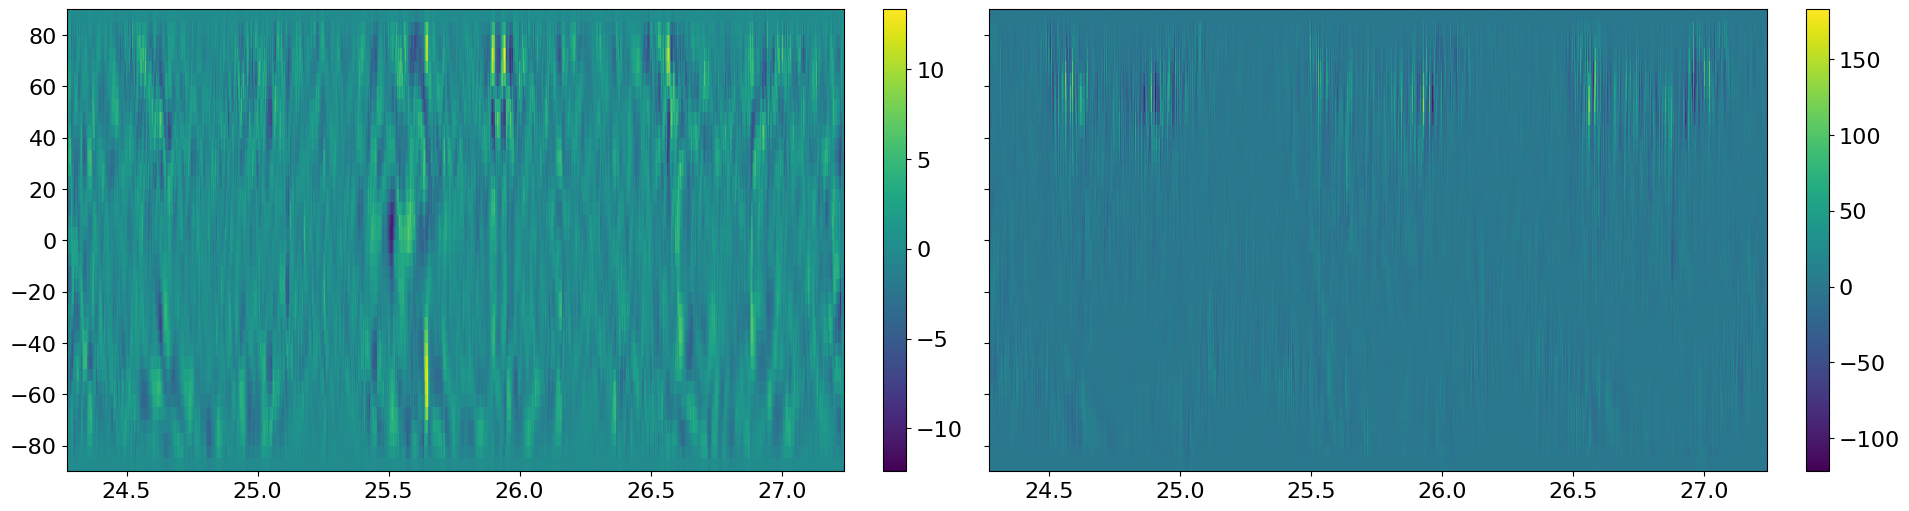

In [5]:
idxVar=np.argwhere((MYlss>30.15)&(MYs!=34))[:,0]
conv=31
cutoff=1/100 #sols
ops=1 #output per sol (using daily data now)

#calculate anomalies from climatology
uZonalAnom,uZonalClimFFT=fft_anom(uZonal, cutoff, ops)
uZonalAnomWeight,uZonalClimWeightFFT=fft_anom(uZonalWeight, cutoff, ops)
ekeZonalAnom,ekeZonalClimFFT=fft_anom(ekeZonal, cutoff, ops)
ekeZonalAnomWeight,ekeZonalClimWeightFFT=fft_anom(ekeZonalWeight, cutoff, ops)
momFluxZonalAnom,ekeZonalClimWeightFFT=fft_anom(momFluxZonal, cutoff, ops)
heatFluxZonalAnom,ekeZonalClimWeightFFT=fft_anom(heatFluxZonal, cutoff, ops)

#detrend anomalies from climatology
uZonalAnom,_,_,_=simple_detrend(uZonalAnom)
uZonalAnomWeight,_,_,_=simple_detrend(uZonalAnomWeight)
momFluxZonalAnom,_,_,_=simple_detrend(momFluxZonalAnom)
heatFluxZonalAnom,_,_,_=simple_detrend(heatFluxZonalAnom)
ekeZonalAnom,_,_,_=simple_detrend(ekeZonalAnom)
ekeZonalAnomWeight,_,_,_=simple_detrend(ekeZonalAnomWeight)

fig, axs = plt.subplots(1, 2, constrained_layout=True, figsize=(19,5), sharex=False, sharey=True)
ax=axs.flat[0]
pcol1=ax.pcolormesh(MYlss,lats,(np.squeeze(ekeZonalAnomWeight[11,:,:])))
plt.colorbar(pcol1)
ax=axs.flat[1]
pcol1=ax.pcolormesh(MYlss,lats,(np.squeeze(heatFluxZonalAnom[11,:,:])))
plt.colorbar(pcol1)

fig, axs = plt.subplots(1, 2, constrained_layout=True, figsize=(19,5), sharex=False, sharey=True)
ax=axs.flat[0]
pcol1=ax.pcolormesh(MYlss,lats,(np.squeeze(uZonalAnomWeight[11,:,:])))
plt.colorbar(pcol1)
ax=axs.flat[1]
pcol1=ax.pcolormesh(MYlss,lats,(np.squeeze(momFluxZonalAnom[11,:,:])))
plt.colorbar(pcol1)

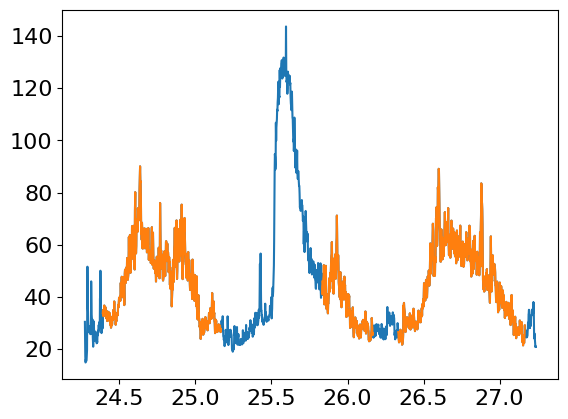

In [6]:
idxEOFLsNot180=np.empty(0).astype(int)
#index for NH of all times NOT to use
ranges=np.array([[24,50,140], [25,60,300], [26,60,120], [27,60,120], [28,0,300], [29,50,180], [29,310,360], [30,0,40], [31,90,120], [32,90,160], [33,110,150]])
for i in range(0,np.shape(ranges)[0]):
    idxEOFLsNot180=np.concatenate((idxEOFLsNot180,np.argwhere(((lss[:]>ranges[i,1])&(lss[:]<ranges[i,2])&(MYs[:]==ranges[i,0])))[:,0]))

ekeZonalWeightNH=np.nanmean(ekeZonalWeight[:,:90,:],axis=(0,1))
plt.plot(MYlss,ekeZonalWeightNH)

ekeZonalWeightNH[idxEOFLsNot180]=np.nan
plt.plot(MYlss,ekeZonalWeightNH)

#set up all of the time indexes
idxEOFNot=np.argwhere((MYlss[:]>34.4)&(MYlss[:]<35))[:,0]  #index excluding all valid times
idxEOFLsNot0=np.argwhere(((lss[:]>190)&(lss[:]<350))|((MYlss[:]>34.4)&(MYlss[:]<35)))[:,0]  #index excluding global dust storm (GDS) and between ls=190–350 for SH
#idxEOFLsNot180=np.argwhere(((lss[:]>10)&(lss[:]<170))|((MYlss[:]>34.4)&(MYlss[:]<35)))[:,0] #index excluding global dust storm (GDS) and between ls=10-170  #older version

nlags=181
idxEOF=np.argwhere((MYlss[:]<34.4)|(MYlss[:]>35))[:,0]  #index for all valid times
MYlssEOF=MYlss[idxEOF]
MYsEOF=MYs[idxEOF]
lssEOF=lss[idxEOF]

idxEOFLs180=np.argwhere((((lss[:]>140)&(lss[:]<360)&((MYlss[:]<34.4)|(MYlss[:]>35)))|((lss[:]<40)&((MYlss[:]<34.4)|(MYlss[:]>35)))))[:,0] #index for all valid times 140–360
MYlssEOFLs180=MYlss[idxEOFLs180]
MYsEOFLs180=MYs[idxEOFLs180]
lssEOFLs180=lss[idxEOFLs180]

idxEOFLs0=np.argwhere((((lss[:]>0)&(lss[:]<210)&((MYlss[:]<34.4)|(MYlss[:]>35)))|((lss[:]>330)&((MYlss[:]<34.4)|(MYlss[:]>35)))))[:,0] #index for all valid times 0–210
MYlssEOFLs0=MYlss[idxEOFLs0]
MYsEOFLs0=MYs[idxEOFLs0]
lssEOFLs0=lss[idxEOFLs0]


In [7]:
#NAM
varin=uZonalAnomWeight[lev1:lev2,idx75N:idx25N,:]
varin[np.isnan(varin)]=0
varProj=(momFluxZonalAnom[lev1:lev2,idx75N:idx25N,:]*sqrtLats[None,idx75N:idx25N,None])
varProj[np.isnan(varProj)]=0
#AMpcs,AMeofs,AMreconstr,AMvarfrac,CI,UAM,MAM,AMlags,AMeofs2D,AMlambdas,AMnorth
#the idxEOFNot kwarg is a time index of when NOT to calculate the EOF
NAM=EOF_wrapper(varin,idxEOFNot=idxEOFNot,varProj=varProj,nlags=nlags,oneD=False)
#NAMLs0=EOF_wrapper(varin,idxEOFNot=idxEOFLsNot0,varProj=varProj,nlags=nlags,oneD=False)
NAMLs180=EOF_wrapper(varin,idxEOFNot=idxEOFLsNot180,varProj=varProj,nlags=nlags,oneD=False)
#note any "insufficient x or y values" error is handled in the wrapper function.  It's only with reducing the confidence on variance estimate for each PC due to lower dof


Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y 

In [8]:
#NBAM
EKEZonalStarAnomWeightYr=np.copy(ekeZonalAnomWeight[:,:,:])
EKEZonalStarAnomWeightYr[:,:,idxEOFNot]=0
EKEZonalStarAnomWeightYr[np.isnan(EKEZonalStarAnomWeightYr)]=0
varin=EKEZonalStarAnomWeightYr[lev1:lev2,idx75N:idx25N,:]
varProj=(heatFluxZonalAnom[lev1:lev2,idx75N:idx25N,:]*sqrtLats[None,idx75N:idx25N,None])
varProj[np.isnan(varProj)]=0
#AMpcs,AMeofs,AMreconstr,AMvarfrac,CI,UAM,MAM,AMlags,AMeofs2D,AMlambdas,AMnorth
NBAM=EOF_wrapper(varin,idxEOFNot=idxEOFNot,varProj=varProj,nlags=nlags,oneD=False)
#NBAMLs0=EOF_wrapper(varin,idxEOFNot=idxEOFLsNot0,varProj=varin,nlags=nlags,oneD=False)
NBAMLs180=EOF_wrapper(varin,idxEOFNot=idxEOFLsNot180,varProj=varProj,nlags=nlags,oneD=False)


Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y values to perform statistics
Insufficient x or y 

In [9]:
var1=np.copy(uZonalAnomWeight[:,:,:])/10
var2=np.copy(ekeZonalAnomWeight[:,:,:])/1000
var1[:,:,idxEOFLsNot180]=np.nan
var2[:,:,idxEOFLsNot180]=np.nan

plot1,_,_,_,_=simple_stats_nan(NAM[5][:,0],var1[:,:,:],norm=True)  #norm=True normalizes PC by its standard deviation
plot2,_,_,_,_=simple_stats_nan(NAMLs180[5][:,0],var1[:,:,:],norm=True)
plot3,_,_,_,_=simple_stats_nan(NBAM[5][:,0],var2[:,:,:],norm=True)
plot4,_,_,_,_=simple_stats_nan(NBAMLs180[5][:,0],var2[:,:,:],norm=True)

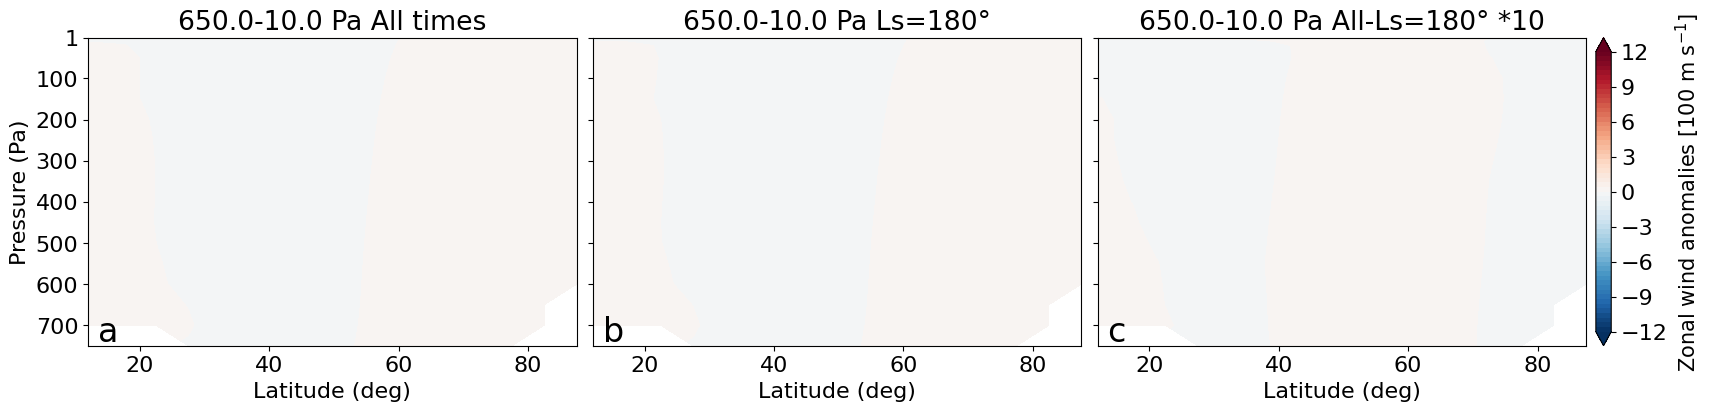

In [10]:
fig, axs = plt.subplots(1, 3, constrained_layout=True, figsize=(17,4), sharex=False, sharey=True)
MX=12
clevs,labels = set_cBar(MX)

ax=axs.flat[0]
cs = ax.contourf(lats,plevs, (plot1[:,:].squeeze()), clevs, cmap=plt.cm.RdBu_r, extend='both')
ax.text(0.02, .1, "a", transform=ax.transAxes, fontsize=24, verticalalignment='top',color='black')
ax.set_title(str(plevs[lev1])+"-"+str(plevs[lev2])+" Pa All times")
ax.set_ylabel(r'Pressure (Pa)')

ax=axs.flat[1]
cs = ax.contourf(lats,plevs, (plot2[:,:].squeeze())*-1, clevs, cmap=plt.cm.RdBu_r, extend='both')
ax.text(0.02, .1, "b", transform=ax.transAxes, fontsize=24, verticalalignment='top',color='black')
ax.set_title(str(plevs[lev1])+"-"+str(plevs[lev2])+" Pa Ls=180°")

ax=axs.flat[2]
cs = ax.contourf(lats,plevs, (plot1[:,:].squeeze()+plot2[:,:].squeeze())*10, clevs, cmap=plt.cm.RdBu_r, extend='both')
ax.text(0.02, .1, "c", transform=ax.transAxes, fontsize=24, verticalalignment='top',color='black')
ax.set_title(str(plevs[lev1])+"-"+str(plevs[lev2])+" Pa All-Ls=180° *10")

cb = plt.colorbar(cs,aspect=20,extend='both',pad=.02)
cb.set_ticks(labels)
cb.set_label(r'Zonal wind anomalies [100 m s$^{-1}$]', fontsize=15)

plt.setp(axs[:], xlabel="Latitude (deg)",xlim=[12,np.max(lats)], ylim=[plevs[1],plevs[lev2]], yticks=np.array((700,600,500,400,300,200,100,1)))
plt.show()

#plt.savefig("figures/NAM_"+reanalysis+"_domainsensitivity_NH.png")


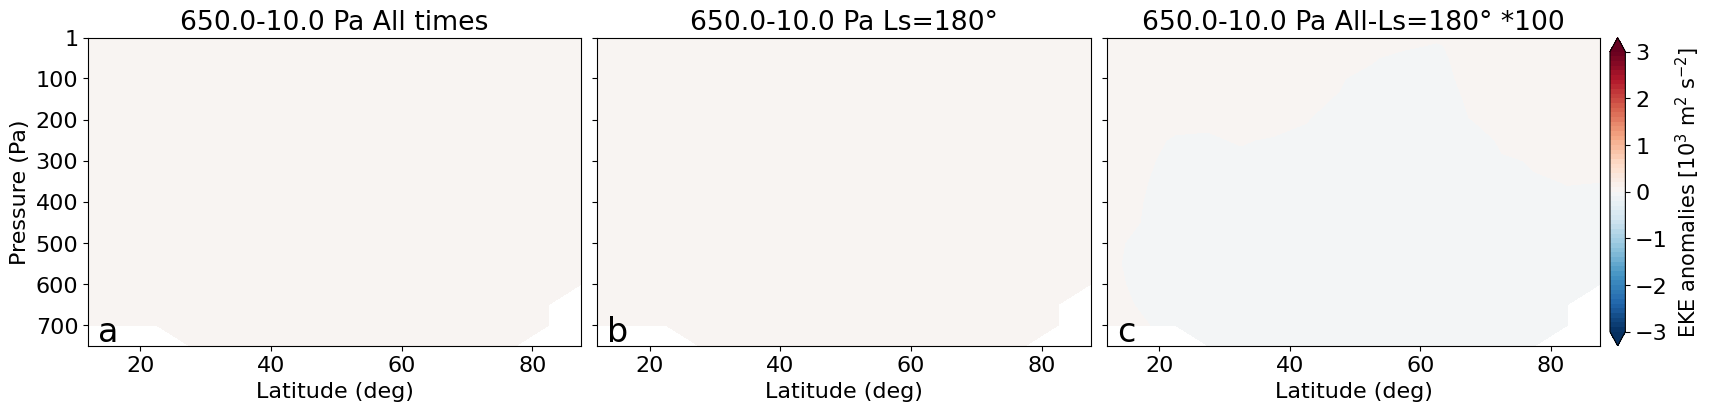

In [11]:
fig, axs = plt.subplots(1, 3, constrained_layout=True, figsize=(17,4), sharex=False, sharey=True)
MX=3
clevs,labels = set_cBar(MX)
ax=axs.flat[0]

cs = ax.contourf(lats,plevs, (plot3[:,:].squeeze()), clevs, cmap=plt.cm.RdBu_r, extend='both')
ax.text(0.02, .1, "a", transform=ax.transAxes, fontsize=24, verticalalignment='top',color='black')
ax.set_title(str(plevs[lev1])+"-"+str(plevs[lev2])+" Pa All times")
ax.set_ylabel(r'Pressure (Pa)')

ax=axs.flat[1]
cs = ax.contourf(lats,plevs, (plot4[:,:].squeeze()), clevs, cmap=plt.cm.RdBu_r, extend='both')
ax.text(0.02, .1, "b", transform=ax.transAxes, fontsize=24, verticalalignment='top',color='black')
ax.set_title(str(plevs[lev1])+"-"+str(plevs[lev2])+" Pa Ls=180°")

ax=axs.flat[2]
cs = ax.contourf(lats,plevs, (plot3[:,:].squeeze()-plot4[:,:].squeeze())*100, clevs, cmap=plt.cm.RdBu_r, extend='both')
ax.text(0.02, .1, "c", transform=ax.transAxes, fontsize=24, verticalalignment='top',color='black')
ax.set_title(str(plevs[lev1])+"-"+str(plevs[lev2])+" Pa All-Ls=180° *100")

cb = plt.colorbar(cs,aspect=20,extend='both',pad=.02)
cb.set_ticks(labels)
cb.set_label(r'EKE anomalies [10$^3$ m$^{2}$ s$^{-2}$]', fontsize=15)
plt.setp(axs[:], xlabel="Latitude (deg)",xlim=[12,np.max(lats)], ylim=[plevs[1],plevs[lev2]], yticks=np.array((700,600,500,400,300,200,100,1)))
plt.show()

#plt.savefig("figures/NBAM_"+reanalysis+"_domainsensitivity_NH.png")


<h4>Calculate power spectra</h4>

In [12]:
#AMpcs,AMeofs,AMreconstr,AMvarfrac,CI,UAM,MAM,AMlags,AMeofs2D,AMlambdas,AMnorthTest
N=8
Nreal=3 #number of realizaions
timeseries=np.copy(NBAM[5][:,0])
pSpecNBAM=welch_powerspectrum(timeseries,N=N,Nreal=Nreal) #freq,pAve,pAveM95,pAveP95,rspec,rspecM95,rspecP95

timeseries=np.copy(NBAMLs180[5][:,0])
timeseries[idxEOFLs180]=np.nan
pSpecNBAMLs180=welch_powerspectrum(timeseries,N=N,Nreal=Nreal) #freq,pAve,pAveM95,pAveP95,rspec,rspecM95,rspecP95

timeseries=np.copy(NAM[5][:,0])
pSpecNAM=welch_powerspectrum(timeseries,N=N,Nreal=Nreal) #freq,pAve,pAveM95,pAveP95,rspec,rspecM95,rspecP95

timeseries=np.copy(NAMLs180[5][:,0])
timeseries[idxEOFLs180]=np.nan
pSpecNAMLs180=welch_powerspectrum(timeseries,N=N,Nreal=Nreal) #freq,pAve,pAveM95,pAveP95,rspec,rspecM95,rspecP95


0.505 1.46
0.67 2.5
0.876 7.55
0.91 10.62


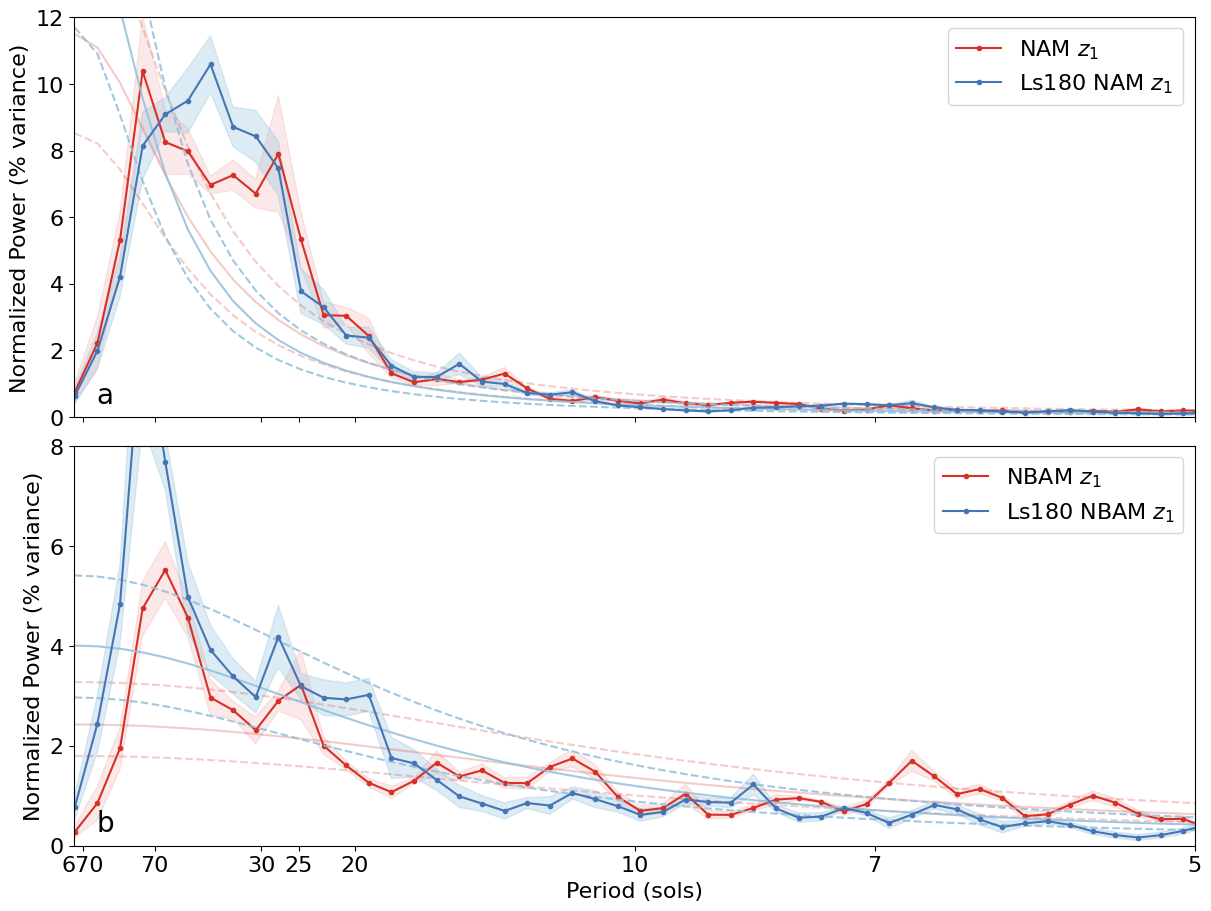

In [13]:
# plot power spectrum and red noise spectra
fig, axs = plt.subplots(2, 1, figsize=(12, 9), constrained_layout=True, sharex=True, sharey=False)

ax=axs.flat[0] #first NAM panel
ax.text(0.02, 0.09, "a", transform=ax.transAxes, fontsize=20, verticalalignment='top',color='black')
ax.plot((pSpecNAM[0]),100*(pSpecNAM[4][:]),'-', alpha=.25, label = 'red-noise fit', color=colors[0])
ax.plot((pSpecNAM[0]),100*(pSpecNAM[5][:]),'--', alpha=.25, color=colors[0])
ax.plot((pSpecNAM[0]),100*(pSpecNAM[6][:]),'--', alpha=.25, color=colors[0])
ax.fill_between(pSpecNAM[0], 100*(pSpecNAM[2][:]), 100*(pSpecNAM[3][:]),color=colors[0], alpha=.1)
pt1,=ax.plot((pSpecNAM[0]),100*pSpecNAM[1][:],'-o', markersize=3, color=colors[0],label = r'NAM $z_1$')

ax.plot((pSpecNAMLs180[0]),100*(pSpecNAMLs180[4][:]),'-', alpha=.85, label = 'red-noise fit', color=colors[2])
ax.plot((pSpecNAMLs180[0]),100*(pSpecNAMLs180[5][:]),'--', alpha=.85, color=colors[2])
ax.plot((pSpecNAMLs180[0]),100*(pSpecNAMLs180[6][:]),'--', alpha=.85, color=colors[2])
ax.fill_between(pSpecNAMLs180[0], 100*(pSpecNAMLs180[2][:]), 100*(pSpecNAMLs180[3][:]),color=colors[2], alpha=.3)
pt2,=ax.plot((pSpecNAMLs180[0]),100*pSpecNAMLs180[1][:],'-o', markersize=3, color=colors[3],label = r'Ls180 NAM $z_1$ ')
ax.legend(handles=[pt1,pt2])

ax=axs.flat[1]  #second NBAM panel
ax.text(0.02, 0.09, "b", transform=ax.transAxes, fontsize=20, verticalalignment='top',color='black')
ax.plot((pSpecNBAM[0]),100*(pSpecNBAM[4][:]),'-', alpha=.25, label = 'red-noise fit', color=colors[0])
ax.plot((pSpecNBAM[0]),100*(pSpecNBAM[5][:]),'--', alpha=.25, color=colors[0])
ax.plot((pSpecNBAM[0]),100*(pSpecNBAM[6][:]),'--', alpha=.25, color=colors[0])
ax.fill_between(pSpecNBAM[0], 100*(pSpecNBAM[2][:]), 100*(pSpecNBAM[3][:]),color=colors[0], alpha=.1)
pt1,=ax.plot((pSpecNBAM[0]),100*pSpecNBAM[1][:],'-o', markersize=3, color=colors[0],label = r'NBAM $z_1$')

ax.plot((pSpecNBAMLs180[0]),100*(pSpecNBAMLs180[4][:]),'-', alpha=.85, label = 'red-noise fit', color=colors[2])
ax.plot((pSpecNBAMLs180[0]),100*(pSpecNBAMLs180[5][:]),'--', alpha=.85, color=colors[2])
ax.plot((pSpecNBAMLs180[0]),100*(pSpecNBAMLs180[6][:]),'--', alpha=.85, color=colors[2])
ax.fill_between(pSpecNBAMLs180[0], 100*(pSpecNBAMLs180[2][:]), 100*(pSpecNBAMLs180[3][:]),color=colors[2], alpha=.3)
pt2,=ax.plot((pSpecNBAMLs180[0]),100*pSpecNBAMLs180[1][:],'-o', markersize=3, color=colors[3],label = r'Ls180 NBAM $z_1$')
ax.legend(handles=[pt1,pt2])

plt.setp(axs[:], xlim=[-0.0002,1/5],yticks=np.arange(0,10)*2,
         xticks=1/np.array((670,70,30,25,20,10,7,5)),xticklabels=np.array((670,70,30,25,20,10,7,5)).astype(int))
plt.setp(axs[:], ylabel="Normalized Power (% variance)")
plt.setp(axs[1], xlabel="Period (sols)",ylim=[0,8])
plt.setp(axs[0], ylim=[0,12])

#print(np.nanmean(pSpecJet[1])/np.nanmax(np.diff(pSpec[0])),1/np.nanmax(np.diff(pSpec[0])),1/pSpec[0][4])
#plt.savefig("figures/improved_frequency"+reanalysis+"_NH_SH_10ls_Nov26.pdf", bbox_inches='tight')
plt.show()